In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Missing value analysis

missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_table)

             Missing Count  Missing Percentage
PassengerId              0            0.000000
Survived                 0            0.000000
Pclass                   0            0.000000
Name                     0            0.000000
Sex                      0            0.000000
Age                    177           19.865320
SibSp                    0            0.000000
Parch                    0            0.000000
Ticket                   0            0.000000
Fare                     0            0.000000
Cabin                  687           77.104377
Embarked                 2            0.224467


In [5]:
# Find columns with more than 20% missing values
high_missing = missing_table[
    missing_table["Missing Percentage"] > 20
]

# Display the result
print("\nColumns with more than 20% missing values:\n")
print(high_missing)


Columns with more than 20% missing values:

       Missing Count  Missing Percentage
Cabin            687           77.104377


In [6]:
# Fill missing values

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df[["Age", "Embarked"]].isna().sum())

Age         0
Embarked    0
dtype: int64


In [7]:
# # Check Cabin missing percentage

print(round(df["Cabin"].isna().mean() * 100, 2), "%")

77.1 %


In [8]:
# Count duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the total number of duplicate rows
print("\nNumber of Duplicate Rows:", duplicate_rows)


Number of Duplicate Rows: 0


In [9]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


In [10]:
# Check null percentage after removing duplicates

missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / df.shape[0]) * 100

missing_data = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percentage.round(2)
})

print(missing_data)

             Missing Values  Percentage
PassengerId               0         0.0
Survived                  0         0.0
Pclass                    0         0.0
Name                      0         0.0
Sex                       0         0.0
Age                       0         0.0
SibSp                     0         0.0
Parch                     0         0.0
Ticket                    0         0.0
Fare                      0         0.0
Cabin                   687        77.1
Embarked                  0         0.0


In [11]:
memory_before = df.memory_usage(deep=True).sum()

df["Sex"] = df["Sex"].astype("category")

memory_after = df.memory_usage(deep=True).sum()

print(memory_before)
print(memory_after)

292500
245756


In [12]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [13]:
# Save the cleaned dataset

df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [14]:
# Check the cleaned dataset

cleaned_data = pd.read_csv("cleaned_data.csv")

print(cleaned_data.shape)

cleaned_data.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# Preview the cleaned dataset

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [17]:
# Save the final cleaned dataset

df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv created successfully.")

cleaned_data.csv created successfully.


In [18]:
# Summary statistics

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
# check skewness

numeric_columns = df.select_dtypes(include=["int64", "float64"])

print(numeric_columns.skew())

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.510245
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64


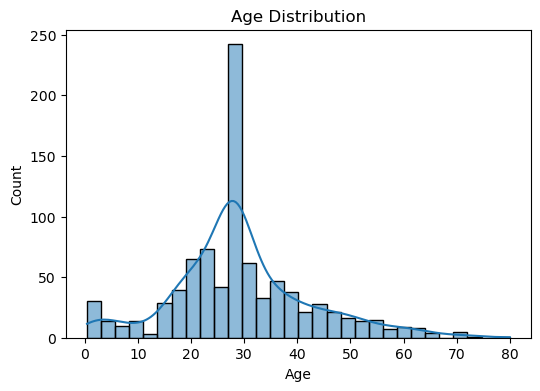

In [20]:
# age distribution

plt.figure(figsize=(6, 4))
sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

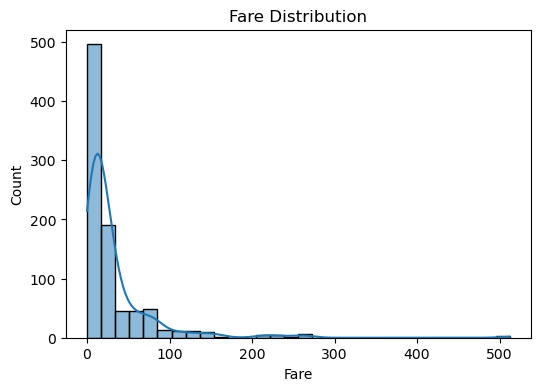

In [21]:
# fare distribution

plt.figure(figsize=(6, 4))
sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.savefig("fare_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

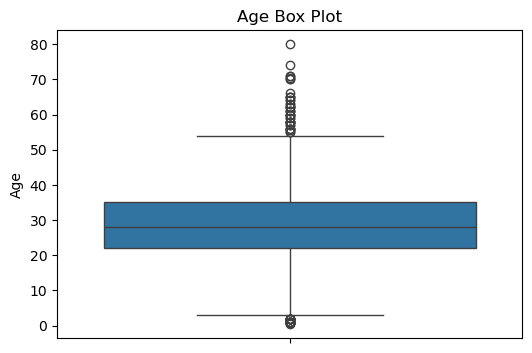

In [22]:
# age box plot

plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Age"])

plt.title("Age Box Plot")
plt.savefig("age_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

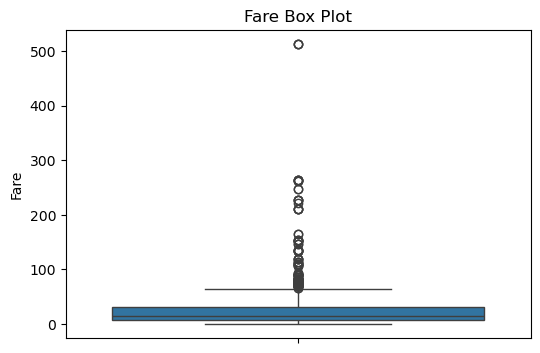

In [23]:
# ffare box plot

plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Fare"])

plt.title("Fare Box Plot")
plt.savefig("fare_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

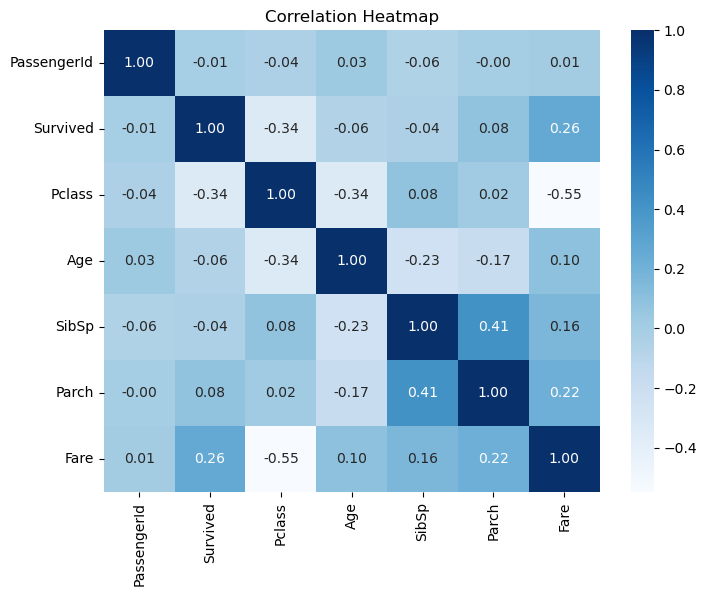

In [24]:
# Check the relationship between numerical columns

plt.figure(figsize=(8, 6))

numeric_data = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
# compare the average fare for each passenger class

class_summary = df.groupby("Pclass")["Fare"].mean()

print(class_summary)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [26]:
# compare survival based on gender

gender_summary = df.groupby("Sex")["Survived"].mean()

print(gender_summary)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


C:\Users\Aiswarya\AppData\Local\Temp\ipykernel_28596\4280601061.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_summary = df.groupby("Sex")["Survived"].mean()


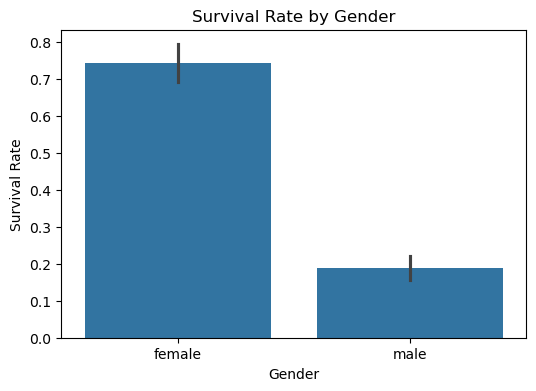

In [27]:
# Show survival rate by gender

plt.figure(figsize=(6, 4))

sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.savefig("survival_rate_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

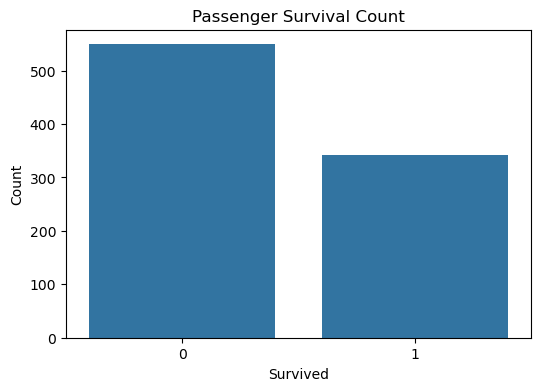

In [28]:
# see how many passengers survived

plt.figure(figsize=(6, 4))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Count")
plt.xlabel("Survived")
plt.savefig("passenger_class.png", dpi=300, bbox_inches="tight")

plt.ylabel("Count")

plt.show()

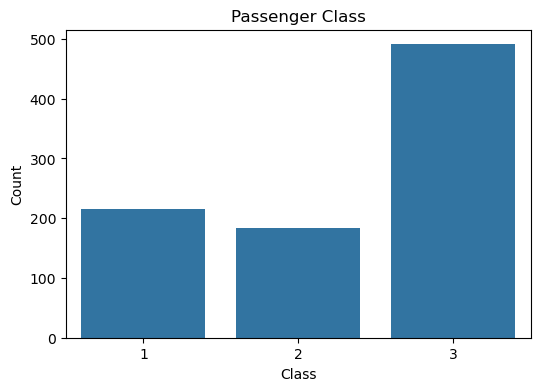

In [29]:
# Check passenger classes

plt.figure(figsize=(6, 4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [30]:
# Pearson correlation

pearson_corr = numeric_data.corr(method="pearson")

print(pearson_corr)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [31]:
# Spearman correlation

spearman_corr = numeric_data.corr(method="spearman")

print(spearman_corr)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.034091  0.034584 -0.061161  0.001235   
Survived       -0.005007  1.000000 -0.339668 -0.037004  0.088879  0.138266   
Pclass         -0.034091 -0.339668  1.000000 -0.317406 -0.043019 -0.022801   
Age             0.034584 -0.037004 -0.317406  1.000000 -0.145316 -0.217488   
SibSp          -0.061161  0.088879 -0.043019 -0.145316  1.000000  0.450014   
Parch           0.001235  0.138266 -0.022801 -0.217488  0.450014  1.000000   
Fare           -0.013975  0.323736 -0.688032  0.126006  0.447113  0.410074   

                 Fare  
PassengerId -0.013975  
Survived     0.323736  
Pclass      -0.688032  
Age          0.126006  
SibSp        0.447113  
Parch        0.410074  
Fare         1.000000  


In [32]:
# Compare Pearson and Spearman

comparison = pd.DataFrame({
    "Pearson": pearson_corr["Fare"],
    "Spearman": spearman_corr["Fare"]
})

display(comparison)

,Pearson,Spearman
PassengerId,0.012658,-0.013975
Survived,0.257307,0.323736
Pclass,-0.549500,-0.688032
Age,0.096688,0.126006
SibSp,0.159651,0.447113
Parch,0.216225,0.410074
Fare,1.000000,1.000000


In [33]:
# Check memory usage

print(df.memory_usage(deep=True))

Index            132
PassengerId     7128
Survived        7128
Pclass          7128
Name           67685
Sex             1107
Age             7128
SibSp           7128
Parch           7128
Ticket         49674
Fare            7128
Cabin          32712
Embarked       44550
dtype: int64


In [34]:
# Final dataset overview

print("Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Shape : (891, 12)

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

Duplicate Rows : 0


In [35]:
# Save the cleaned data

df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv saved successfully.")

cleaned_data.csv saved successfully.


In [36]:
# Load the cleaned file

cleaned_data = pd.read_csv("cleaned_data.csv")

cleaned_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


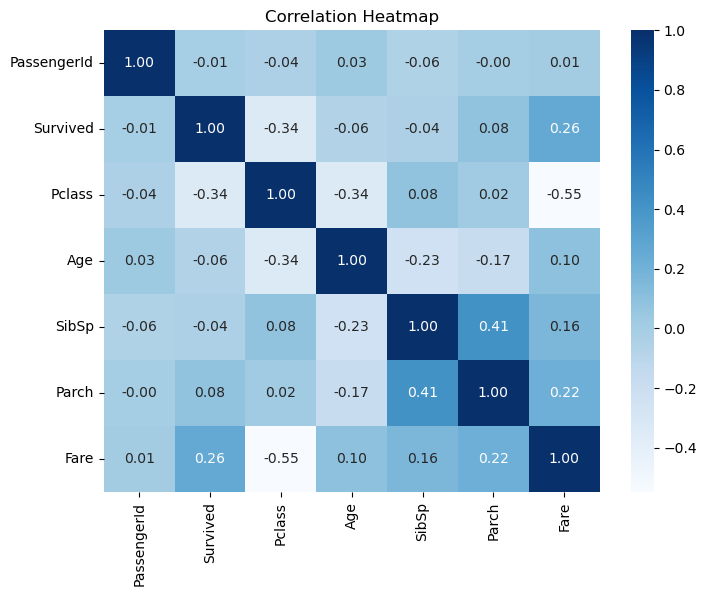

In [37]:
# See the relationship between numerical columns

plt.figure(figsize=(8, 6))

numeric_data = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap_2.png", dpi=300, bbox_inches="tight")

plt.show()

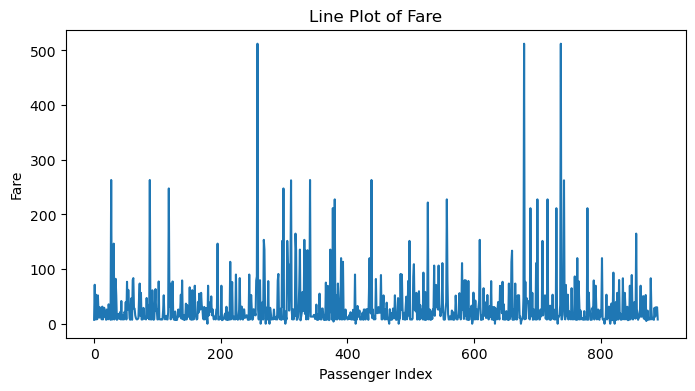

In [38]:
# Line plot

plt.figure(figsize=(8, 4))

plt.plot(df.index, df["Fare"])

plt.title("Line Plot of Fare")
plt.xlabel("Passenger Index")
plt.ylabel("Fare")
plt.savefig("line_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

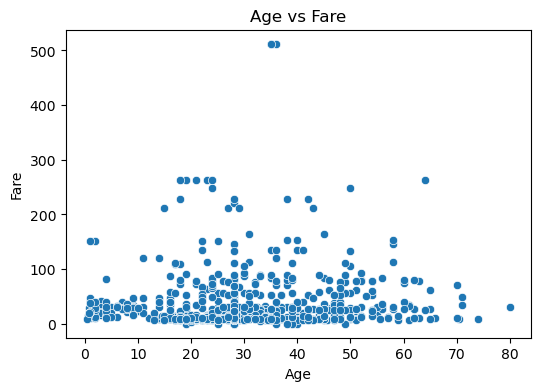

In [39]:
# Scatter plot

plt.figure(figsize=(6, 4))

sns.scatterplot(data=df, x="Age", y="Fare")

plt.title("Age vs Fare")
plt.savefig("scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()

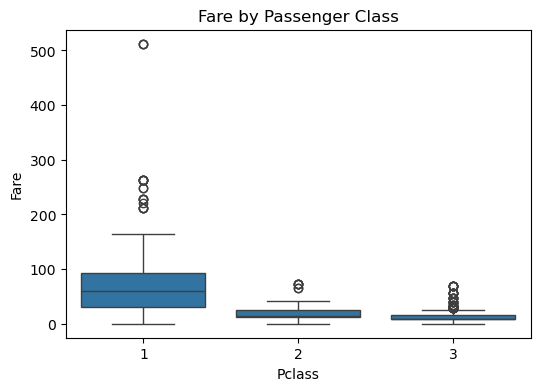

In [40]:
# Box plot

plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="Pclass", y="Fare")

plt.title("Fare by Passenger Class")
plt.savefig("box_plot.png", dpi=300, bbox_inches="tight")


plt.show()

In [41]:
# IQR for Age

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

age_outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]

print("Age Outliers:", len(age_outliers))

Age Outliers: 66


In [42]:
# IQR for Fare

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

fare_outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]

print("Fare Outliers:", len(fare_outliers))

Fare Outliers: 116


In [43]:
# Mean and median comparison

skew_values = df.select_dtypes(include=["int64", "float64"]).skew().abs()

top_two = skew_values.sort_values(ascending=False).head(2).index

comparison = pd.DataFrame({
    "Mean": [df[col].mean() for col in top_two],
    "Median": [df[col].median() for col in top_two]
}, index=top_two)

print(comparison)

print(df[top_two].isnull().sum())

            Mean   Median
Fare   32.204208  14.4542
SibSp   0.523008   0.0000
Fare     0
SibSp    0
dtype: int64


In [44]:
# Pearson and Spearman correlation

pearson = df.select_dtypes(include=["int64", "float64"]).corr()

spearman = df.select_dtypes(include=["int64", "float64"]).corr(method="spearman")

print("Pearson Correlation")
print(pearson)

print("\nSpearman Correlation")
print(spearman)

Pearson Correlation
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  

Spearman Correlation
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.034091  0.034584 -0.06116

In [45]:
# Difference table

difference = (spearman - pearson).abs()

difference_pairs = difference.unstack()

difference_pairs = difference_pairs[difference_pairs < 1]

difference_pairs = difference_pairs.sort_values(ascending=False)

print(difference_pairs.head(3))

SibSp  Fare     0.287462
Fare   SibSp    0.287462
Parch  Fare     0.193849
dtype: float64


In [46]:
# Grouped aggregation

group_data = df.groupby("Pclass")["Fare"].agg(["mean", "std", "count"])

print(group_data)

             mean        std  count
Pclass                             
1       84.154687  78.380373    216
2       20.662183  13.417399    184
3       13.675550  11.778142    491


In [47]:
# Mean ratio

highest_mean = group_data["mean"].max()

lowest_mean = group_data["mean"].min()

ratio = highest_mean / lowest_mean

print("Mean Ratio:", round(ratio, 2))

Mean Ratio: 6.15


In [48]:
# Save cleaned dataset

df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
